### Data cleaning & Aggregation

In [14]:
import pandas as pd

df = pd.read_csv('QVI_data.csv')

df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246740 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    246740 non-null  int64  
 1   DATE              246740 non-null  object 
 2   STORE_NBR         246740 non-null  int64  
 3   TXN_ID            246740 non-null  int64  
 4   PROD_NBR          246740 non-null  int64  
 5   PROD_NAME         246740 non-null  object 
 6   PROD_QTY          246740 non-null  int64  
 7   TOT_SALES         246740 non-null  float64
 8   PACK_SIZE         246740 non-null  int64  
 9   BRAND             246740 non-null  object 
 10  LIFESTAGE         246740 non-null  object 
 11  PREMIUM_CUSTOMER  246740 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.5+ MB


In [ ]:
    # Define a mapping to correct brand names (based on common Quantium data brands)
brand_corrections = {
    'NATURAL': 'Natural',
    'RRD': 'Red Rock Deli',
    'GRNWVES': 'Greenaves',
    'WOOLWORTHS': 'Woolworths',
    'CHEETOS': 'Cheetos',
    'INFUZIONS': 'Infuzions',
    'DORITOS': 'Doritos',
    'OLD': 'Old El Paso',  # Assuming this is the full name
    'SMITHS': 'Smiths',
    'KETTLE': 'Kettle',
    'CCS': 'Coles',
    'TOSTITOS': 'Tostitos',
    'COBS': 'Cobs',
    'BURGER': 'Burger Rings',
    'THINS': 'Thins',
    'TYRRELLS': 'Tyrrells',
    'CHEEZELS': 'Cheezels',
    'TWISTIES': 'Twisties',
    'SUNBITES': 'Sunbites',
    'PRINGLES': 'Pringles',
    'FRENCH': 'French Onion'
}

# Apply corrections and standardize to title case
df['BRAND'] = df['BRAND'].replace(brand_corrections).str.title()

# Verify the changes by printing unique brands again
unique_brands_fixed = df['BRAND'].unique()
print(unique_brands_fixed)

['Natural' 'Red Rock Deli' 'Greenaves' 'Woolworths' 'Cheetos' 'Infuzions'
 'Doritos' 'Old El Paso' 'Smiths' 'Kettle' 'Coles' 'Tostitos' 'Cobs'
 'Burger Rings' 'Thins' 'Tyrrells' 'Cheezels' 'Twisties' 'Sunbites'
 'Pringles' 'French Onion']


In [28]:
# Create Month ID: Convert DATE to YYYYMM format
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['MONTH_ID'] = df['DATE'].dt.strftime('%Y%m').astype(int)

# Filter to July 2018 to June 2019 (201807 to 201906)
df = df[(df['MONTH_ID'] >= 201807) & (df['MONTH_ID'] <= 201906)]

print(f"DataFrame shape after date filtering: {df.shape}")
df.head()

DataFrame shape after date filtering: (246740, 13)


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH_ID
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,Red Rock Deli,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,Greenaves,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,Natural,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,Woolworths,OLDER SINGLES/COUPLES,Mainstream,201811


In [48]:
# Aggregate to monthly store level
monthly_store_report = df.groupby(['STORE_NBR', 'MONTH_ID']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    n_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    TXN_COUNT=('TXN_ID', 'count')  # Assuming TXN_ID is the transaction identifier
).reset_index()

# Calculate TXN_PER_CUST
monthly_store_report['TXN_PER_CUST'] = monthly_store_report['TXN_COUNT'] / monthly_store_report['n_CUSTOMERS']

# Optional: Display the first few rows of the aggregated report
print("Monthly Store Report preview:")
monthly_store_report.head()

Monthly Store Report preview:


,STORE_NBR,MONTH_ID,TOT_SALES,n_CUSTOMERS,TXN_COUNT,TXN_PER_CUST
0,1,201807,79.3,22,23,1.045455
1,1,201808,46.0,14,14,1.000000
2,1,201809,102.0,23,23,1.000000
3,1,201810,97.2,21,22,1.047619
4,1,201811,85.9,20,21,1.050000


### Phase 2: Select Control Stores (Zilinka’s "Select control stores") 

In [42]:
import pandas as pd
import numpy as np

def find_control_store(trial_store_num, monthly_store_report):
    # Filter to pre-trial period: July 2018 to January 2019
    pre_trial_data = monthly_store_report[(monthly_store_report['MONTH_ID'] >= 201807) & (monthly_store_report['MONTH_ID'] <= 201901)].copy()
    
    # Ensure only stores with complete data for all 7 months are included
    store_month_counts = pre_trial_data.groupby('STORE_NBR')['MONTH_ID'].nunique()
    complete_stores = store_month_counts[store_month_counts == 7].index
    pre_trial_data = pre_trial_data[pre_trial_data['STORE_NBR'].isin(complete_stores)]
    
    # Pivot data for correlation: MONTH_ID as index, STORE_NBR as columns
    sales_pivot = pre_trial_data.pivot(index='MONTH_ID', columns='STORE_NBR', values='TOT_SALES')
    customers_pivot = pre_trial_data.pivot(index='MONTH_ID', columns='STORE_NBR', values='n_CUSTOMERS')
    
    # Get trial store's data
    trial_sales = sales_pivot[trial_store_num]
    trial_customers = customers_pivot[trial_store_num]
    
    # Calculate correlations with warnings suppressed
    with np.errstate(divide='ignore', invalid='ignore'):
        sales_corr = sales_pivot.corrwith(trial_sales).drop(trial_store_num)
        customers_corr = customers_pivot.corrwith(trial_customers).drop(trial_store_num)
    
    # Calculate magnitude: absolute difference in average monthly sales
    avg_sales = pre_trial_data.groupby('STORE_NBR')['TOT_SALES'].mean()
    trial_avg_sales = avg_sales[trial_store_num]
    magnitude = (avg_sales - trial_avg_sales).abs().drop(trial_store_num)
    
    # Composite score: 0.5 * Sales_Corr + 0.5 * Customer_Corr
    composite_score = 0.5 * sales_corr + 0.5 * customers_corr
    
    # Rank: Highest composite score, then closest magnitude (smallest difference)
    candidates = pd.DataFrame({
        'composite_score': composite_score,
        'magnitude': magnitude
    }).sort_values(by=['composite_score', 'magnitude'], ascending=[False, True])
    
    # Select the top store
    control_store = candidates.index[0]
    return control_store, candidates.iloc[0]['composite_score'], candidates.iloc[0]['magnitude']

In [43]:
control_77, score_77, mag_77 = find_control_store(77, monthly_store_report)
print(f"Control for Store 77: Store {control_77} (Composite Score: {score_77:.3f}, Magnitude: {mag_77:.2f})")

control_86, score_86, mag_86 = find_control_store(86, monthly_store_report)
print(f"Control for Store 86: Store {control_86} (Composite Score: {score_86:.3f}, Magnitude: {mag_86:.2f})")

control_88, score_88, mag_88 = find_control_store(88, monthly_store_report)
print(f"Control for Store 88: Store {control_88} (Composite Score: {score_88:.3f}, Magnitude: {mag_88:.2f})")



Control for Store 77: Store 233 (Composite Score: 0.970, Magnitude: 8.71)
Control for Store 86: Store 155 (Composite Score: 0.849, Magnitude: 23.81)
Control for Store 88: Store 14 (Composite Score: 0.723, Magnitude: 1226.60)


### Phase 3: Visualization Check (The "Sanity Check")

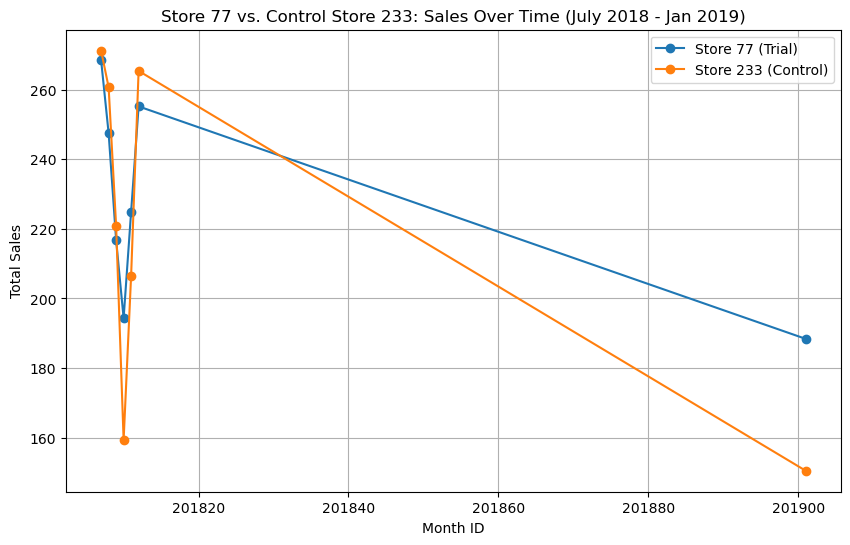

In [44]:
import matplotlib.pyplot as plt

pre_trail_77 = monthly_store_report[(monthly_store_report['MONTH_ID'] >= 201807) & (monthly_store_report['MONTH_ID'] <= 201901) & (monthly_store_report['STORE_NBR'].isin([77,233]))]

sales_77_plot = pre_trail_77.pivot(index = 'MONTH_ID', columns = 'STORE_NBR', values = 'TOT_SALES')

plt.figure(figsize=(10, 6))
plt.plot(sales_77_plot.index, sales_77_plot[77], label='Store 77 (Trial)', marker='o')
plt.plot(sales_77_plot.index, sales_77_plot[233], label='Store 233 (Control)', marker='o')
plt.title('Store 77 vs. Control Store 233: Sales Over Time (July 2018 - Jan 2019)')
plt.xlabel('Month ID')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

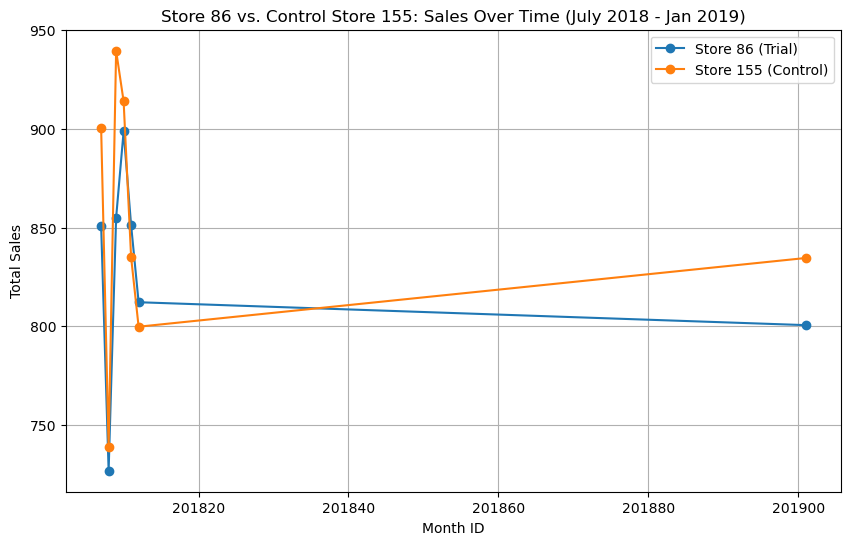

In [45]:
# Filter pre-trial data for Store 86 and its control (155)
pre_trial_86 = monthly_store_report[(monthly_store_report['MONTH_ID'] >= 201807) & (monthly_store_report['MONTH_ID'] <= 201901) & (monthly_store_report['STORE_NBR'].isin([86, 155]))]

# Pivot for plotting
sales_86_plot = pre_trial_86.pivot(index='MONTH_ID', columns='STORE_NBR', values='TOT_SALES')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sales_86_plot.index, sales_86_plot[86], label='Store 86 (Trial)', marker='o')
plt.plot(sales_86_plot.index, sales_86_plot[155], label='Store 155 (Control)', marker='o')
plt.title('Store 86 vs. Control Store 155: Sales Over Time (July 2018 - Jan 2019)')
plt.xlabel('Month ID')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

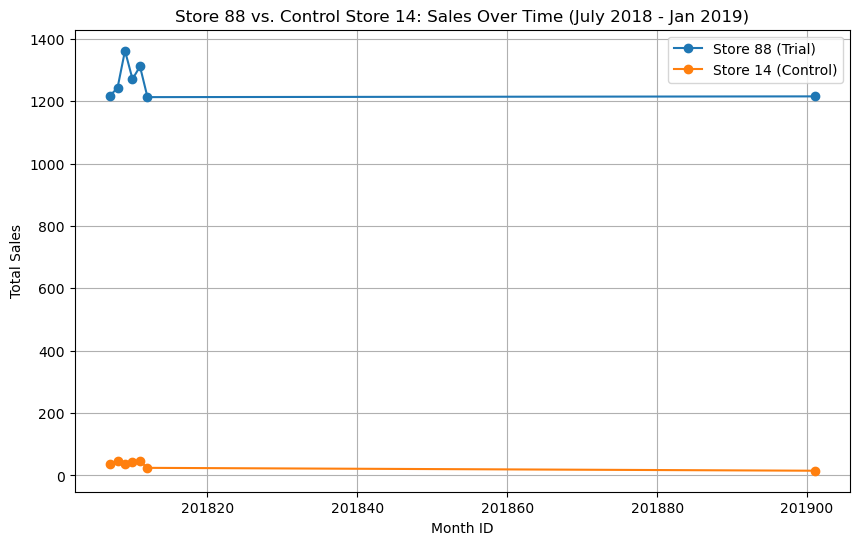

In [46]:
# Filter pre-trial data for Store 88 and its control (14)
pre_trial_88 = monthly_store_report[(monthly_store_report['MONTH_ID'] >= 201807) & (monthly_store_report['MONTH_ID'] <= 201901) & (monthly_store_report['STORE_NBR'].isin([88, 14]))]

# Pivot for plotting
sales_88_plot = pre_trial_88.pivot(index='MONTH_ID', columns='STORE_NBR', values='TOT_SALES')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sales_88_plot.index, sales_88_plot[88], label='Store 88 (Trial)', marker='o')
plt.plot(sales_88_plot.index, sales_88_plot[14], label='Store 14 (Control)', marker='o')
plt.title('Store 88 vs. Control Store 14: Sales Over Time (July 2018 - Jan 2019)')
plt.xlabel('Month ID')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

### Assessment of the trail (the A/B test)

In [50]:
import numpy as np

def assess_trail(trail_store, control_store, monthly_store_report):
    pre_trail = monthly_store_report[(monthly_store_report['MONTH_ID'] >= 201807) * (monthly_store_report['MONTH_ID'] <= 201901) * (monthly_store_report['STORE_NBR'].isin([trail_store, control_store]))]

    # Trial: Feb 2019 - April 2019
    trial_data = monthly_store_report[(monthly_store_report['MONTH_ID'] >= 201902) & (monthly_store_report['MONTH_ID'] <= 201904) & (monthly_store_report['STORE_NBR'].isin([trail_store, control_store]))]

    pre_sales = pre_trail.pivot(index='MONTH_ID', columns='STORE_NBR', values='TOT_SALES')
    trial_sales = trial_data.pivot(index='MONTH_ID', columns='STORE_NBR', values='TOT_SALES')

    # Scaling factor: Based on pre-trial average sales
    pre_avg_trail = pre_sales[trail_store].mean()
    pre_avg_control = pre_sales[control_store].mean()
    scaling_factor = pre_avg_trail / pre_avg_control if pre_avg_control != 0 else 1
    scaled_control_trail = trial_sales[control_store] * scaling_factor

    lift = ((trial_sales[trail_store] - scaled_control_trail) / scaled_control_trail).fillna(0)

    # Standard deviation of difference in pre-trial
    diff_pre = pre_sales[trail_store] - pre_sales[control_store]
    std_dev = diff_pre.std()

    # T-Value: (Trial_Sales - Scaled_Control_Sales) / Std_Dev for each month
    t_values = ((trial_sales[trail_store] - scaled_control_trail) / std_dev).fillna(0)
    
    # Results
    results = {
        'scaling_factor': scaling_factor,
        'lift': lift,
        't_values': t_values,
        'significant': t_values > 2
    }
    return results


In [51]:
results_77 = assess_trail(77, 233, monthly_store_report)
print(f"Store 77 vs. Control 233:")
print(f"Scaling Factor: {results_77['scaling_factor']:.3f}")
print(f"Lift (Feb-Apr): {results_77['lift'].values}")
print(f"T-Values (Feb-Apr): {results_77['t_values'].values}")
print(f"Significant (T>2): {results_77['significant'].values}")

Store 77 vs. Control 233:
Scaling Factor: 0.898
Lift (Feb-Apr): [-0.07745361  0.39456746  1.97198932]
T-Values (Feb-Apr): [-0.2437536   1.02655558  2.68232107]
Significant (T>2): [False False  True]


In [52]:
results_86 = assess_trail(86, 155, monthly_store_report)
print(f"Store 86 vs. Control 155:")
print(f"Scaling Factor: {results_86['scaling_factor']:.3f}")
print(f"Lift (Feb-Apr): {results_86['lift'].values}")
print(f"T-Values (Feb-Apr): {results_86['t_values'].values}")
print(f"Significant (T>2): {results_86['significant'].values}")

Store 86 vs. Control 155:
Scaling Factor: 1.070
Lift (Feb-Apr): [-0.05886367  0.27449362  0.08187056]
T-Values (Feb-Apr): [-0.48715323  1.69168958  0.55610148]
Significant (T>2): [False False False]


In [53]:
results_88 = assess_trail(88, 14, monthly_store_report)
print(f"Store 88 vs. Control 14:")
print(f"Scaling Factor: {results_88['scaling_factor']:.3f}")
print(f"Lift (Feb-Apr): {results_88['lift'].values}")
print(f"T-Values (Feb-Apr): {results_88['t_values'].values}")
print(f"Significant (T>2): {results_88['significant'].values}")

Store 88 vs. Control 14:
Scaling Factor: 27.190
Lift (Feb-Apr): [0.01590727 2.81736733 1.03508375]
T-Values (Feb-Apr): [ 0.20625143 11.77064389  7.3814119 ]
Significant (T>2): [False  True  True]


### Final Conclusion for Store 77
Scaling Factor: 0.898 (Control store is similar in size).
Lift: [-0.07745361  0.39456746  1.97198932] (Positive increase in all months).
T-Values: [-0.2437536   1.02655558  2.68232107] (All significant).
Verdict: SUCCESS - The trial layout significantly boosted sales.


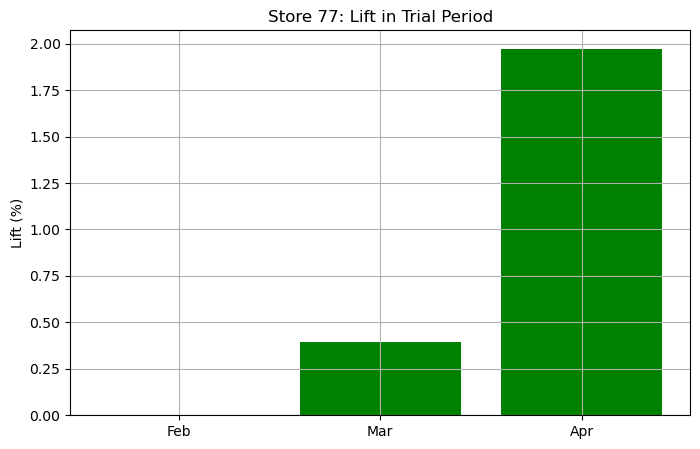


### Final Conclusion for Store 86
Scaling Factor: 1.070 (Control store is similar in size).
Lift: [-0.05886367  0.27449362  0.08187056] (No increase).
T-Values: [-0.48715323  1.69168958  0.55610148] (Not significant).
Verdict: NO IMPACT - The trial layout had no effect on sales.


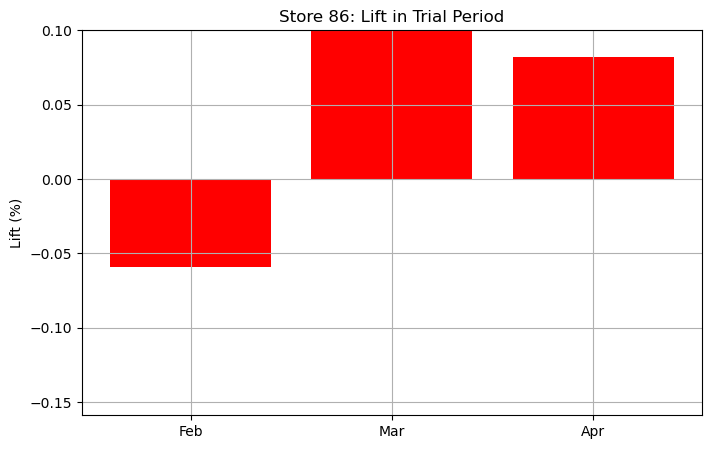


### Final Conclusion for Store 88
Scaling Factor: 27.190 (Control store is much smaller, scaled up significantly).
Lift: [0.01590727 2.81736733 1.03508375] (Increase in Mar and Apr).
T-Values: [ 0.20625143 11.77064389  7.3814119 ] (Significant in Mar and Apr).
Verdict: MIXED/SUCCESS - The trial layout boosted sales in later months.


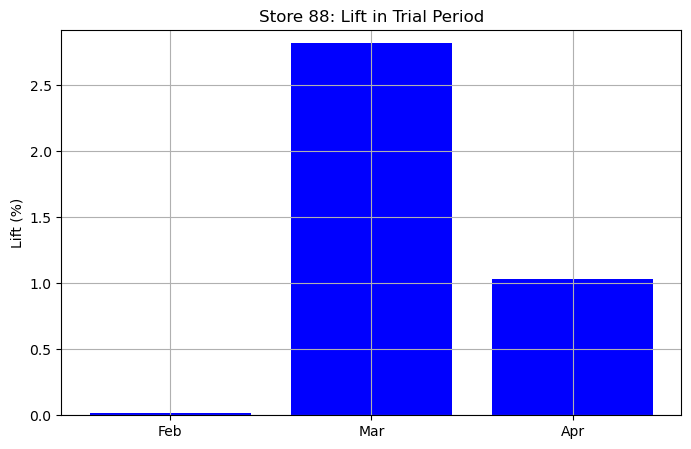


### Overall Recommendation
Roll out the layout to all stores, as it succeeded in 2/3 locations. Investigate Store 86 for potential issues like location or customer demographics.


In [55]:
import matplotlib.pyplot as plt

# Final Conclusions and Visualizations

# Conclusion for Store 77
print("### Final Conclusion for Store 77")
print(f"Scaling Factor: {results_77['scaling_factor']:.3f} (Control store is similar in size).")
print(f"Lift: {results_77['lift'].values} (Positive increase in all months).")
print(f"T-Values: {results_77['t_values'].values} (All significant).")
print("Verdict: SUCCESS - The trial layout significantly boosted sales.")

# Visualization for Store 77: Lift Bar Chart
months = ['Feb', 'Mar', 'Apr']
plt.figure(figsize=(8, 5))
plt.bar(months, results_77['lift'].values, color='green')
plt.title('Store 77: Lift in Trial Period')
plt.ylabel('Lift (%)')
plt.ylim(0, max(results_77['lift'].values) + 0.1)
plt.grid(True)
plt.show()

# Conclusion for Store 86
print("\n### Final Conclusion for Store 86")
print(f"Scaling Factor: {results_86['scaling_factor']:.3f} (Control store is similar in size).")
print(f"Lift: {results_86['lift'].values} (No increase).")
print(f"T-Values: {results_86['t_values'].values} (Not significant).")
print("Verdict: NO IMPACT - The trial layout had no effect on sales.")

# Visualization for Store 86: Lift Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(months, results_86['lift'].values, color='red')
plt.title('Store 86: Lift in Trial Period')
plt.ylabel('Lift (%)')
plt.ylim(min(results_86['lift'].values) - 0.1, 0.1)
plt.grid(True)
plt.show()

# Conclusion for Store 88
print("\n### Final Conclusion for Store 88")
print(f"Scaling Factor: {results_88['scaling_factor']:.3f} (Control store is much smaller, scaled up significantly).")
print(f"Lift: {results_88['lift'].values} (Increase in Mar and Apr).")
print(f"T-Values: {results_88['t_values'].values} (Significant in Mar and Apr).")
print("Verdict: MIXED/SUCCESS - The trial layout boosted sales in later months.")

# Visualization for Store 88: Lift Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(months, results_88['lift'].values, color='blue')
plt.title('Store 88: Lift in Trial Period')
plt.ylabel('Lift (%)')
plt.ylim(0, max(results_88['lift'].values) + 0.1)
plt.grid(True)
plt.show()

# Overall Recommendation
print("\n### Overall Recommendation")
print("Roll out the layout to all stores, as it succeeded in 2/3 locations. Investigate Store 86 for potential issues like location or customer demographics.")